In [1]:
from utils.config import DATA_DIR, SAVED_MODELS_DIR, RAW_CONFIG
from pathlib import Path
from models.Unet import UNet
from utils.dataset2 import GLORYSDS2, TestSubset
from utils.splitter import test_indices
import torch
import numpy as np

In [2]:
ds_path = DATA_DIR/RAW_CONFIG['datafile']
data = GLORYSDS2(ds_path)
test_idx = test_indices(Path(f"../../{RAW_CONFIG['test_indices']}"))
test_data = TestSubset(data, test_idx, days=True)

Loaded existing test indices from ../../test_indices/2021_test_stratification.pt, test size: 378


In [3]:
print(len(data))
print(len(test_data))
len(test_data[20])

2214
378


3

In [ ]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data._utils.collate import default_collate

def collate_img_lbl_day(batch):
    imgs, lbls, days = zip(*batch)      # unzip
    imgs  = default_collate(imgs)       # (B, C, H, W)
    lbls  = default_collate(lbls)       # (B, …)
    days  = default_collate(days)       # (B,)  int64
    return imgs, lbls, days

test_loader = DataLoader(
    test_data,            
    batch_size=1,
    shuffle=True,
    collate_fn=collate_img_lbl_day
)
print(len(next(iter(test_loader))))

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
import os
import glob

model_path = SAVED_MODELS_DIR / "training_start_time: 20250520_152727"/"best_model"
model = torch.load(model_path, map_location="cpu", weights_only=False)
model.eval()

unet

In [ ]:
outputs = []
num_outputs = 10

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        print(f"Processing batch {i}, len(batch)={len(batch)}")

        if len(batch) == 3:
            images, labels, days = batch
            day_value = days.item() if isinstance(days, torch.Tensor) else days[0]
            print(f"Day: {day_value}")
            preds = model(images)
            outputs.append((preds, labels, days))
        elif len(batch) == 2:
            images, labels = batch
            print("Warning: No day information available, using default day=0")
            preds = model(images)
            # Create a default day value
            default_day = torch.tensor([0])
            outputs.append((preds, labels, default_day))
        else:
            print(f"Warning: Unexpected batch structure with {len(batch)} elements")
        
        if i >= num_outputs:
            break

2
Processing batch 0, len(batch)=2
Processing batch 1, len(batch)=2
Processing batch 2, len(batch)=2
Processing batch 3, len(batch)=2
Processing batch 4, len(batch)=2
Processing batch 5, len(batch)=2
Processing batch 6, len(batch)=2
Processing batch 7, len(batch)=2
Processing batch 8, len(batch)=2
Processing batch 9, len(batch)=2
Processing batch 10, len(batch)=2


In [ ]:
# Define an improved plotting function to handle extreme values
def plot_var_robust(axis, fig, var, title, clip_percentile=99):
    """
    Plot variable with values clipped to handle extreme values
    
    Parameters:
    - axis: matplotlib axis to plot on
    - fig: matplotlib figure
    - var: numpy array to plot
    - title: title for the plot
    - clip_percentile: percentile to use for clipping extreme values (default 99)
    """
    # Get min and max values
    full_min, full_max = np.min(var), np.max(var)
    
    # Get robust min and max (clipping extreme values)
    if clip_percentile:
        robust_min = np.percentile(var, 1)
        robust_max = np.percentile(var, clip_percentile)
    else:
        robust_min, robust_max = full_min, full_max
    
    # Create the plot with clipped range
    im = axis.imshow(var, origin='lower', cmap='viridis', vmin=robust_min, vmax=robust_max)
    axis.set_title(title)
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
    axis.set_xticks([])
    axis.set_yticks([])
    cbar = fig.colorbar(im, ax=axis)
    cbar.set_label('Depth (m)')
    
    # Add text showing the full data range
    if full_min < robust_min or full_max > robust_max:
        axis.text(0.02, 0.02, f"Full range: {full_min:.1f} to {full_max:.1f}", 
                transform=axis.transAxes, color='white', 
                bbox=dict(facecolor='black', alpha=0.5))

Processing output 0 with day = 0
Unnormalization successful for day 0
Processing output 1 with day = 0
Unnormalization successful for day 0
Processing output 2 with day = 0
Unnormalization successful for day 0
Processing output 3 with day = 0
Unnormalization successful for day 0
Processing output 4 with day = 0
Unnormalization successful for day 0


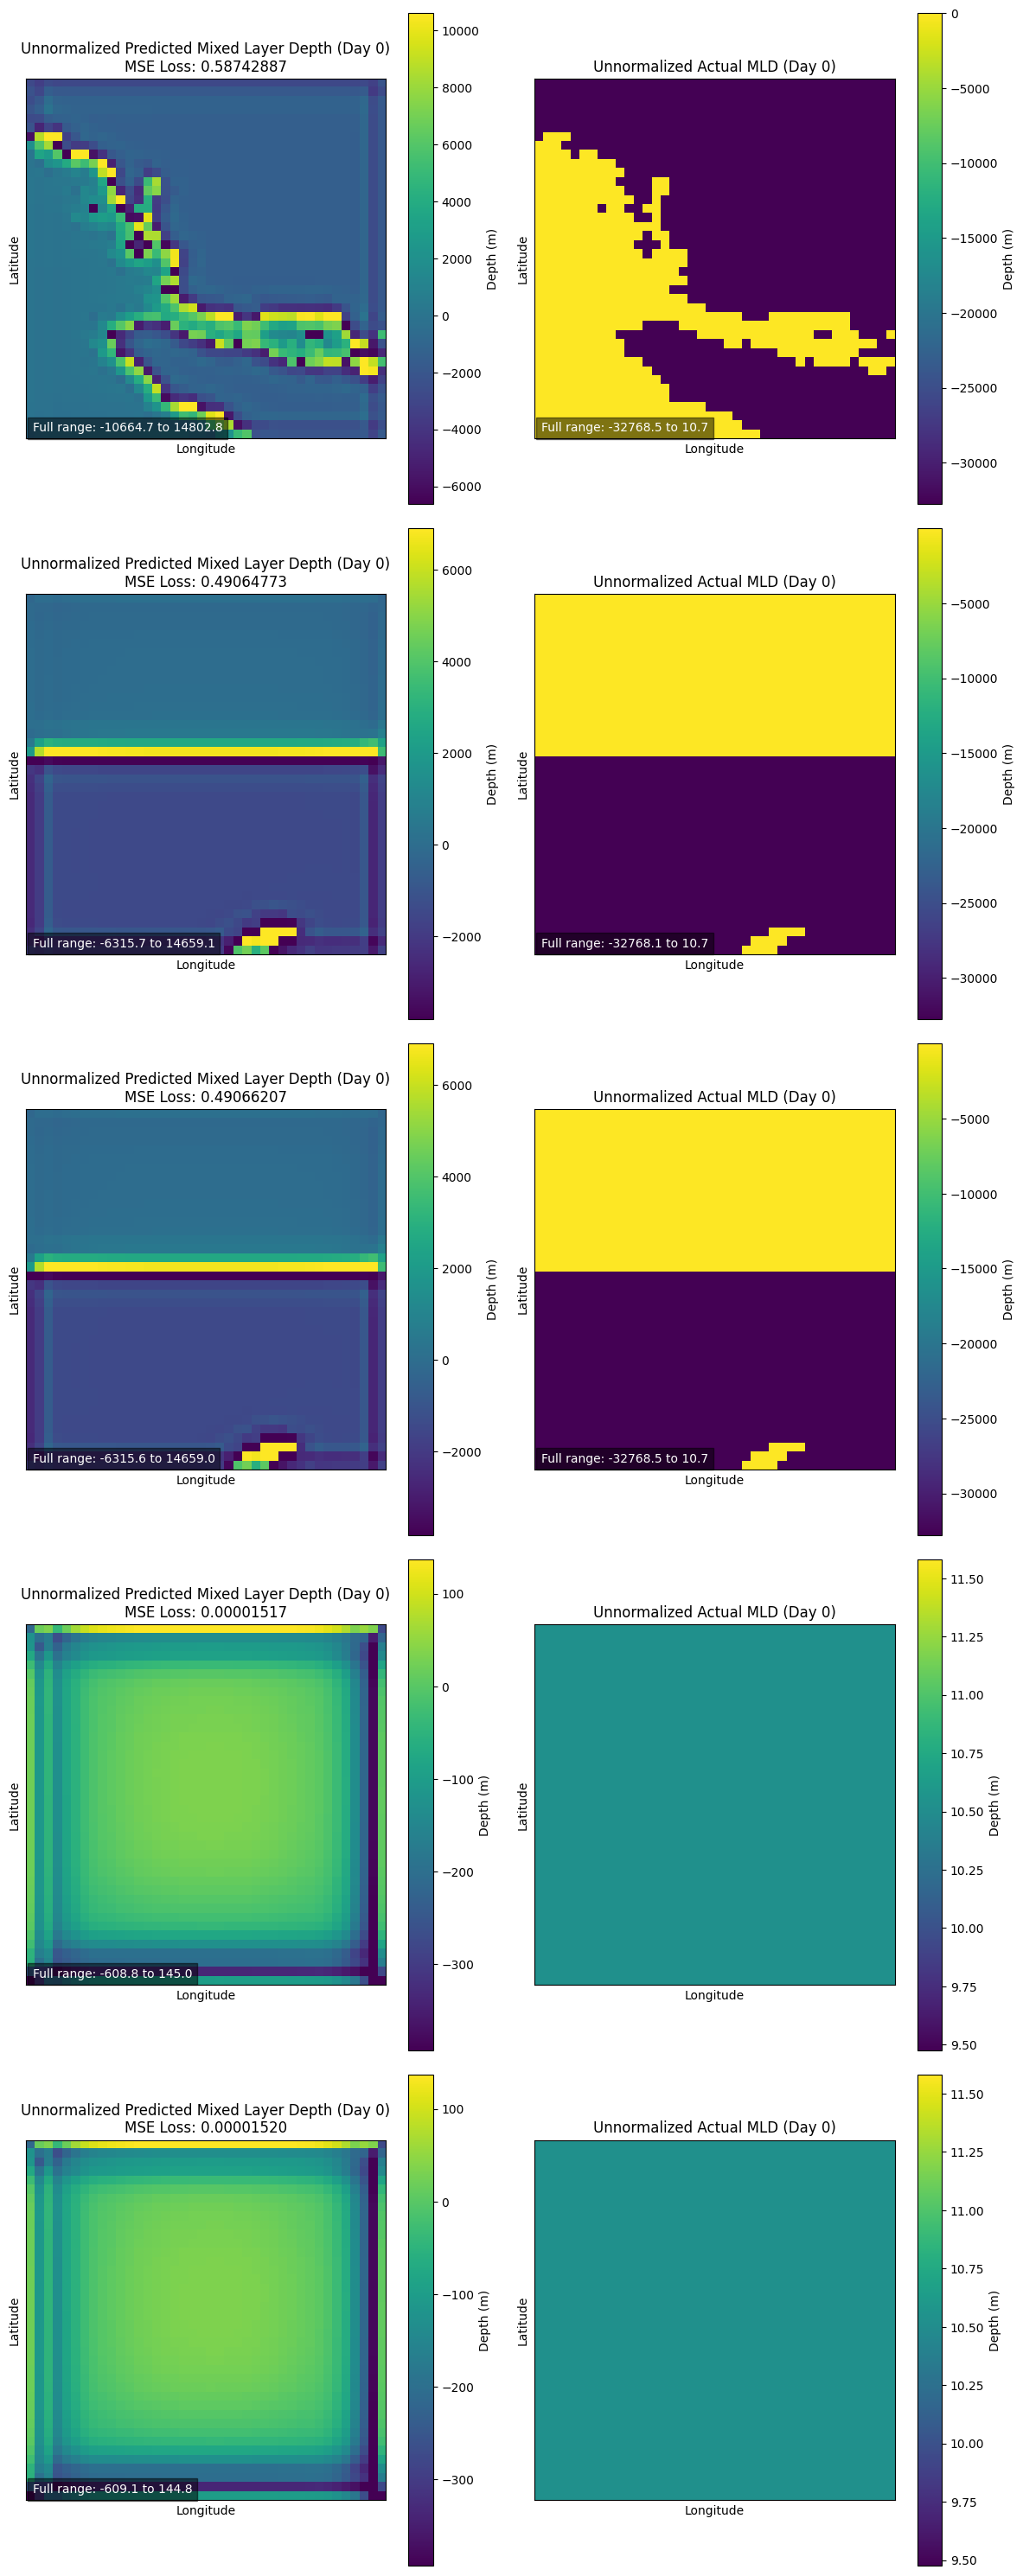

In [ ]:
import matplotlib.pyplot as plt
from utils.handy_plotting_func import plot_var
import numpy as np
import torch.nn.functional as F

# Take fewer samples for better visualization
samples_to_plot = 5
outputs_subset = outputs[:samples_to_plot]

fig, axs = plt.subplots(figsize=(12, 6*len(outputs_subset)), ncols=2, nrows=len(outputs_subset))
for i, output_item in enumerate(outputs_subset):
    try:
        if len(output_item) >= 3:
            pred, label, day_tensor = output_item
            day = day_tensor.item() if hasattr(day_tensor, 'item') else day_tensor[0]
            print(f"Processing output {i} with day = {day}")
        else:
            pred, label = output_item[0], output_item[1]
            day = 0
            print(f"Processing output {i} with default day = 0")
            
        # Convert to numpy if needed
        pred_np = pred.numpy() if isinstance(pred, torch.Tensor) else pred
        label_np = label.numpy() if isinstance(label, torch.Tensor) else label
        
        try:
            # Try to unnormalize with the day information
            pred_unnormalized = data.unnormalize(pred_np, day)
            label_unnormalized = data.unnormalize(label_np, day)
            pred_squeezed = np.squeeze(pred_unnormalized, axis=(0, 1))
            label_squeezed = np.squeeze(label_unnormalized, axis=(0, 1))
            title_prefix = "Unnormalized "
            print(f"Unnormalization successful for day {day}")
            
            # Use robust plotting for better visualization
            plot_var_robust(axs[i, 0], fig, pred_squeezed, 
                          f"{title_prefix}Predicted MLD (Day {day})", clip_percentile=99)
            plot_var_robust(axs[i, 1], fig, label_squeezed, 
                          f"{title_prefix}Actual MLD (Day {day})", clip_percentile=99)
        except Exception as e:
            print(f"Unnormalization failed: {e}. Using normalized values instead.")
            pred_squeezed = np.squeeze(pred_np, axis=(0, 1))
            label_squeezed = np.squeeze(label_np, axis=(0, 1))
            title_prefix = "Normalized "
            
            # Fall back to regular plotting
            plot_var(axs[i, 0], fig, pred_squeezed, f"{title_prefix}Predicted Mixed Layer Depth")
            plot_var(axs[i, 1], fig, label_squeezed, f"{title_prefix}Actual Mixed Layer Depth")

        # Calculate and display loss
        pred_tensor = torch.from_numpy(pred_np) if not isinstance(pred, torch.Tensor) else pred
        label_tensor = torch.from_numpy(label_np) if not isinstance(label, torch.Tensor) else label
        normalized_loss = F.mse_loss(pred_tensor, label_tensor)
        axs[i, 0].set_title(f"{title_prefix}Predicted Mixed Layer Depth (Day {day})\nMSE Loss: {normalized_loss.item():.8f}")
    
    except Exception as e:
        print(f"Error plotting sample {i}: {e}")
        
plt.tight_layout()